## *Frequency Domain* 

## Task 1:

### Importing Libraries 📚

In [8]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from numpy.fft import fft2, ifft2, fftshift, ifftshift

### Load and Preprocess Image 🖼️







In [9]:
# Load image
img = cv2.imread('cameraman.jpg', cv2.IMREAD_GRAYSCALE)
# Convert to float
img = img.astype(np.float32)

### Define Sobel Filters 🔍







In [10]:
sobel_x = np.array([[-1, 0, 1],
                    [-2, 0, 2],
                    [-1, 0, 1]], dtype=np.float32)

sobel_y = np.array([[-1, -2, -1],
                    [ 0,  0,  0],
                    [ 1,  2,  1]], dtype=np.float32)

### Function to Center Kernel and Compute its FFT 🎯







In [11]:
def center_embed_kernel(kernel, shape):
    """
    Pads and centers the kernel in an array of size `shape`, then computes its FFT.
    """
    padded = np.zeros(shape, dtype=np.float32)
    kh, kw = kernel.shape
    ph, pw = shape
    cy, cx = ph // 2, pw // 2
    # Insert kernel centered at the image center
    padded[cy - kh//2:cy - kh//2 + kh, cx - kw//2:cx - kw//2 + kw] = kernel
    # Shift top-left to (0,0) and compute FFT
    return fft2(ifftshift(padded))

### Compute FFT of image and kernels ⚡

In [12]:
# FFT of image
F_img = fft2(img)

# FFT of Sobel kernels
F_sobel_x = center_embed_kernel(sobel_x, img.shape)
F_sobel_y = center_embed_kernel(sobel_y, img.shape)

### Multiply in Frequency Domain ✖️


In [13]:
# Convolve in frequency domain (multiply)
Gx = F_img * F_sobel_x
Gy = F_img * F_sobel_y

# Back to spatial domain
gx = np.real(ifft2(Gx))
gy = np.real(ifft2(Gy))

# Compute gradient magnitude
gradient_magnitude = np.sqrt(gx**2 + gy**2)

### Plot Results 📈


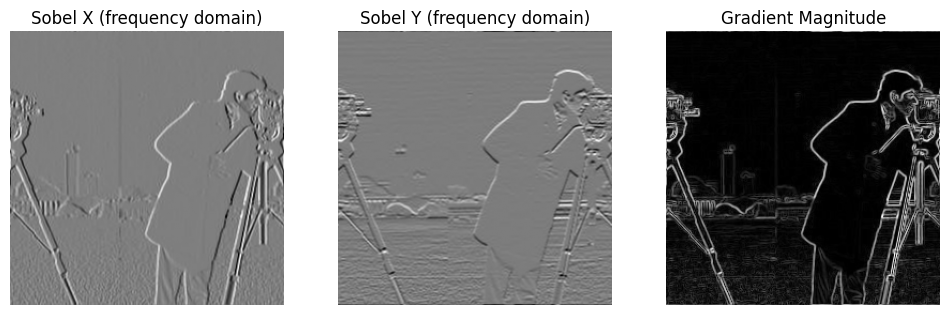

In [14]:
plt.figure(figsize=(12,6))

plt.subplot(1,3,1)
plt.imshow(gx, cmap='gray')
plt.title('Sobel X (frequency domain)')
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(gy, cmap='gray')
plt.title('Sobel Y (frequency domain)')
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(gradient_magnitude, cmap='gray')
plt.title('Gradient Magnitude')
plt.axis('off')

plt.show()